# Cheburashka LoRA Fine-Tuning

This notebook covers the complete workflow for fine-tuning Stable Diffusion v1.5 with LoRA to recognize the **Cheburashka** concept.

## 1. Setup and Project Structure
We have organized the project as follows:
- `data/cheburashka`: 3 training images
- `configs/train_config.yaml`: Hyperparameters
- `dataset.py`: Image loading and preprocessing
- `train.py`: Training pipeline
- `inference.py`: Generation logic

## 2. Stage 1: Raw Model Demo
First, we demonstrate that the base Stable Diffusion model doesn't know what a 'Cheburashka' is.

c:\Users\igors\Projects\CVImageGenerationTraining\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Loading Original Stable Diffusion Pipeline...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 3515.13it/s]]
CLIPTextModel LOAD REPORT from: C:\Users\igors\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 396/396 [00:00<00:00, 2357.34it/s]5.05it/s]
StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\igors\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  

Generating image for prompt: '<cheburashka> with the Eiffel Tower in the background'


100%|██████████| 30/30 [00:03<00:00,  8.66it/s]


Saved results/stage1_raw_model.png
Encoding prompt: '<cheburashka> plushie'
Saved encoded prompt embeddings to data/prompt_embeds.pt
Memory cleaned up.


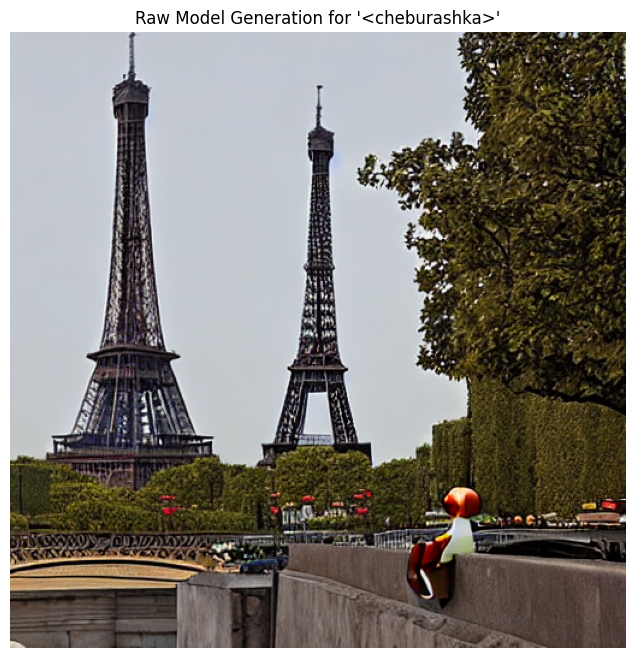

In [1]:
from stage1_demo import run_stage1
import matplotlib.pyplot as plt
from PIL import Image
import os

# Run the demo (generates results/stage1_raw_model.png)
run_stage1()

# Display result
img = Image.open('results/stage1_raw_model.png')
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title("Raw Model Generation for '<cheburashka>'")
plt.axis('off')
plt.show()

## 3. Stage 2: Fine-Tuning with LoRA
Now we run the training process. This will update only the LoRA adapter weights.

In [2]:
from train import train

train("configs/train_config_v2.yaml")

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 9788.69it/s]
CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\igors\Projects\CVImageGenerationTraining\.venv\lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


trainable params: 25,509,888 || all params: 885,030,852 || trainable%: 2.8824


Training:  50%|█████     | 500/1000 [02:39<02:44,  3.04it/s, loss=0.254] 

Saved checkpoint to ./checkpoints_v2\checkpoint-500


Training: 100%|██████████| 1000/1000 [05:24<00:00,  3.05it/s, loss=0.12]  

Saved checkpoint to ./checkpoints_v2\checkpoint-1000
Training completed!


Training: 100%|██████████| 1000/1000 [05:24<00:00,  3.08it/s, loss=0.12]


## 4. Stage 3: Inference and Evaluation
Now we load the trained LoRA weights and generate new images.

Loading base model: runwayml/stable-diffusion-v1-5


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 3518.43it/s]]
CLIPTextModel LOAD REPORT from: C:\Users\igors\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 396/396 [00:00<00:00, 2321.61it/s]4.77it/s]
StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\igors\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  

Loading LoRA weights from: ./checkpoints_v2\lora_final
Generating image 1/4 for prompt: <cheburashka> with the Eiffel Tower in the background


100%|██████████| 30/30 [00:04<00:00,  6.95it/s]


Generating image 2/4 for prompt: <cheburashka> plushie


...

Generating image 3/4 for prompt: <cheburashka> in sketch style


100%|██████████| 30/30 [00:03<00:00,  7.71it/s]
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


Generating image 4/4 for prompt: <cheburashka> riding a bycycle


100%|██████████| 30/30 [00:03<00:00,  7.54it/s]
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


All images saved to ./results_v2


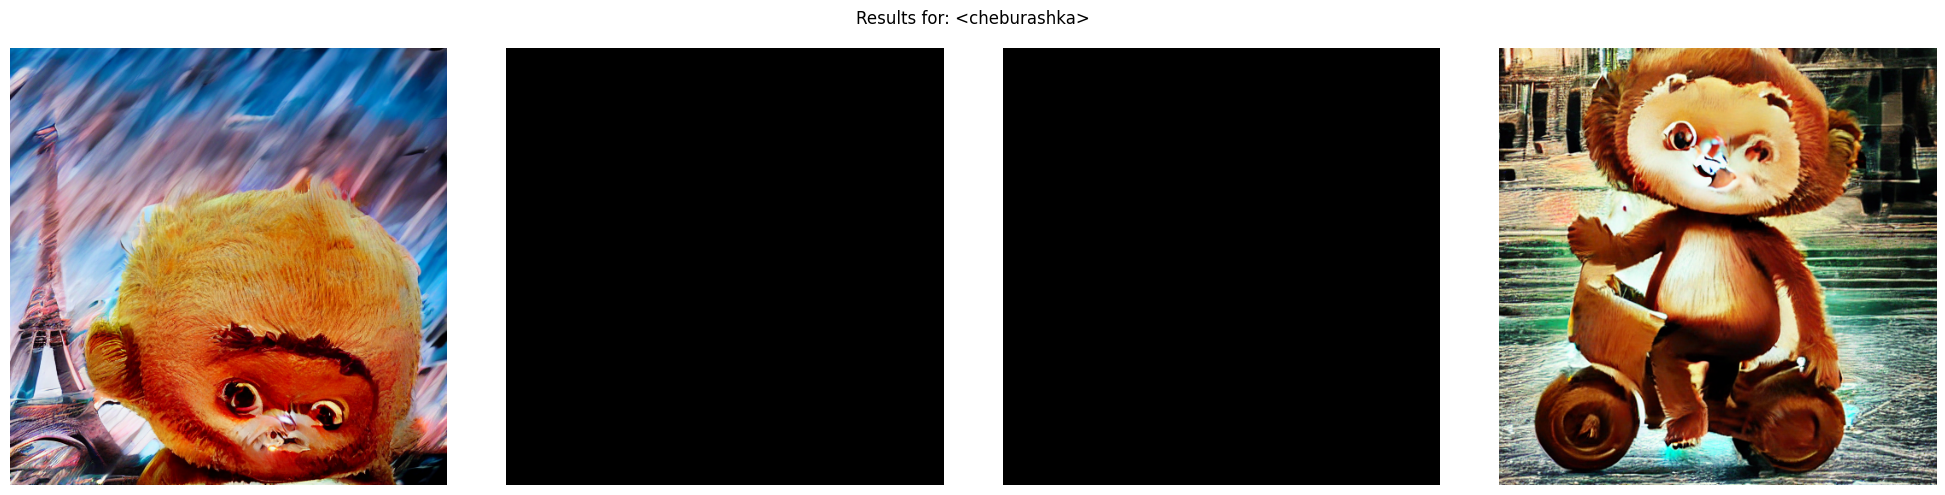

In [3]:
from inference import generate
from utils.visualization import show_results

# Generate new images
generate("configs/train_config_v2.yaml")

# Display results
show_results('results', '<cheburashka>')